In [ ]:
# basic notebook for plotting logos from annotated seqlets for highlighting specific examples #

In [1]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as mpl
import matplotlib
import torch
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
import logomaker

In [2]:
# define a function for reading in data and concatenating #
def read_in_sat_mut (path2satmut, chunksize):
    # define a list for concatenating #
    chunks2cat = []
    # iterate through chunked tsv #
    for chunk in tqdm(pd.read_csv(path2satmut, sep = '\t', chunksize=chunksize)):
        chunks2cat.append(chunk)
    # concatenate chunks #
    cat_df = pd.concat(chunks2cat)
    return cat_df

In [3]:
# load mpac preds
preds = read_in_sat_mut('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/mpac_preds/GRCh38-dELS-chr1-ALL-mpac-017.tsv.gz',
                        1000000)
# get mean preds
groupby_cols = [i for i in preds.keys() if 'k562' in i or 'hepg2' in i or 'sknsh' in i or 'id' in i]
mean_groupy = preds.filter(groupby_cols).groupby('id').mean()

0it [00:00, ?it/s]

104it [03:44,  2.16s/it]


In [4]:
# load recursive seqlet tensors
seqlet_tensors = torch.load('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/chr1_recursive_seqlets_tensors.pt')

In [5]:
# load plotLogo tensors
plotLogo_tensors = torch.load('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/chr1_plotLogo_tensors.pt')

In [6]:
# load annotated seqlets
annotated_seqlets = torch.load('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/annotated_seqlets/chr1_annotated_seqlets_0.01.pt',
                               weights_only=False)

In [7]:
# define a function where we take a random enhancer and plot the thresholds for each cell type
def plot_specific_logos (annotated_seqlets,
                         cell,
                         enhancerID,
                         plotLogo_tensors,
                         save):
    # define colors for each cell type for highlighting logos
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    print(cell)
    # return index of chosen enhancer
    enh_idx = list(plotLogo_tensors['K562'].keys()).index(enhancerID)
    cell_seqlets = annotated_seqlets[cell][0]
    annotation_seqlets = annotated_seqlets[cell][-1]
    # filter for the random enhancer by enhancer index
    enh_seqlets = cell_seqlets[cell_seqlets['example_idx'] == enh_idx]
    enh_ann = annotation_seqlets.iloc[enh_seqlets.index]
    if len(enh_seqlets) > 0:
        mpl.figure(figsize=(20,4), dpi=300)
        ax = mpl.subplot(111)
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        plot_logo(plotLogo_tensors[cell][enhancerID], annotations=enh_ann, score_key='attribution')
        for idx, row in enh_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.25, color=highlight)
        #mpl.ylim(-.5, .5)
        mpl.title(f'tangermeme seqlets for {enhancerID}, threshold: 0.01 | {cell}')
        mpl.tight_layout()
        if save == True:
            mpl.savefig(f'{enhancerID}_sat_mut_logos.pdf')
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[cell][enhancerID])
        mpl.title(f'tangermeme seqlets for {enhancerID}, threshold: 0.01 | {cell}')
        mpl.show()

In [8]:
def plot_specific_enhancers (enhancer_id,
                             enhStart,
                             chrom,
                             collapsedSeqletBED,
                             LeadVar,
                             otherVars,
                             cell,
                             output):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    # load the tensors
    plotLogo_tensors = 
    # get the seqlets for the BED file
    enhBED = collapsedSeqletBED[collapsedSeqletBED['enhancer_id'] == enhancer_id]
    # pull the tensors for the enhancer for that cell type
    tensors2plot = plotLogo_tensors[cell][enhancer_id]
    # get the max/min attributions for highlighting seqlets
    minAttrib = tensors2plot.min().min() * 1.05
    maxAttrib = tensors2plot.max().max() * 1.05
    # build the DF for plotting with logomaker
    dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy() # convert tensor to DF for plotting with logoMaker
    renamedDF = dfFromTensor.rename(columns={0 : 'A', 1 : 'C', 2 : 'G', 3 : 'T'})
    # set plot paramaters
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] == 300
    # generate base plot
    logoCheck = logomaker.Logo(renamedDF, figsize=[20,1.5])
    # highlight seqlets
    for idx, row in enhBED.iterrows():
            start, stop, actClass, tf = row[['start', 'end', 'activity_class', 'tf_family']].tolist() # add attribution score to plot for annotating TFs
            start = start - enhStart # reformat start to match genomic intervals
            stop = stop - enhStart - 1 # reformat end to match genomic intervals
            if actClass == 'Activator':
                logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='blanchedalmond', edgecolor='k', floor=0)
                logoCheck.ax.plot([start, stop],
                [maxAttrib*1.05, maxAttrib*1.05], color='k', linewidth=1, solid_capstyle='butt')
                logoCheck.ax.text((stop+start) / 2,maxAttrib*1.15,f'${tf.split('_')[0]}$',fontsize=8,verticalalignment='top', horizontalalignment='center')
            else:
                logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='blanchedalmond', edgecolor='k', ceiling=0)
                logoCheck.ax.plot([start, stop],
                [maxAttrib*1.05, maxAttrib*1.05], color='k', linewidth=1, solid_capstyle='butt')
                logoCheck.ax.text((stop+start) / 2,maxAttrib*1.15,f'${tf.split('_')[0]}$',fontsize=8,verticalalignment='top', horizontalalignment='center')
    # highlight lead Variant
    # reformat lead var
    LeadVar = LeadVar - enhStart - 1
    logoCheck.highlight_position(p=LeadVar, color='red',alpha=0.5, floor=0)
    # highlight larger effect variants
    for var in otherVars:
        var2plot = var - enhStart - 1
        logoCheck.highlight_position(p=var2plot, color='cyan',alpha=0.5, floor=0)
    logoCheck.style_spines(visible=False)
    mpl.title(f'{enhancer_id}| {cell}', loc='left')

SyntaxError: invalid syntax (369347766.py, line 17)

In [9]:
k_mpac_collapsed_dels.head()

NameError: name 'k_mpac_collapsed_dels' is not defined

In [11]:
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed_dels (path2bed,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    filtered_bed = bed.copy()
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [('_').join(i.split('_')[0:2]) for i in filtered_bed[3]],
                             'tf_family' : [motif_dict.get(('_').join(i.split('_')[0:2])) for i in filtered_bed[3]],
                             'activity_class' : filtered_bed[6],
                             'enhancer_id' : filtered_bed[7]})
    return bed2plot

In [12]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [13]:
# reformat MPAC collapsed BED files
path2beds = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/bed_files'
# k562
k_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_k562_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)
# hepg2
h_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_hepg2_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)
# sknsh
s_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_sknsh_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)

In [14]:
k_mpac_collapsed_dels[k_mpac_collapsed_dels['enhancer_id'] == 'EH38E1314911']

,chrom,start,end,tf,tf_family,activity_class,enhancer_id
8534,chr1,6917243,6917255,ZN281_HUMAN.H11MO.0.A,KLF/SP/2,Activator,EH38E1314911
8535,chr1,6917266,6917277,INSM1_HUMAN.H11MO.0.C,INSM1,Activator,EH38E1314911
8536,chr1,6917280,6917292,SNAI2_HUMAN.H11MO.0.A,Ebox/CACCTG,Repressor,EH38E1314911
8537,chr1,6917280,6917294,SNAI2_HUMAN.H11MO.0.A,Ebox/CACCTG,Activator,EH38E1314911
8538,chr1,6917287,6917298,INSM1_HUMAN.H11MO.0.C,INSM1,Activator,EH38E1314911
8539,chr1,6917288,6917300,SP1_HUMAN.H11MO.0.A,KLF/SP/2,Activator,EH38E1314911
8540,chr1,6917293,6917300,ATF4_HUMAN.H11MO.0.A,CREB/ATF/3,Repressor,EH38E1314911
8541,chr1,6917303,6917309,SNAI1_HUMAN.H11MO.0.C,Ebox/CACCTG,Repressor,EH38E1314911


K562


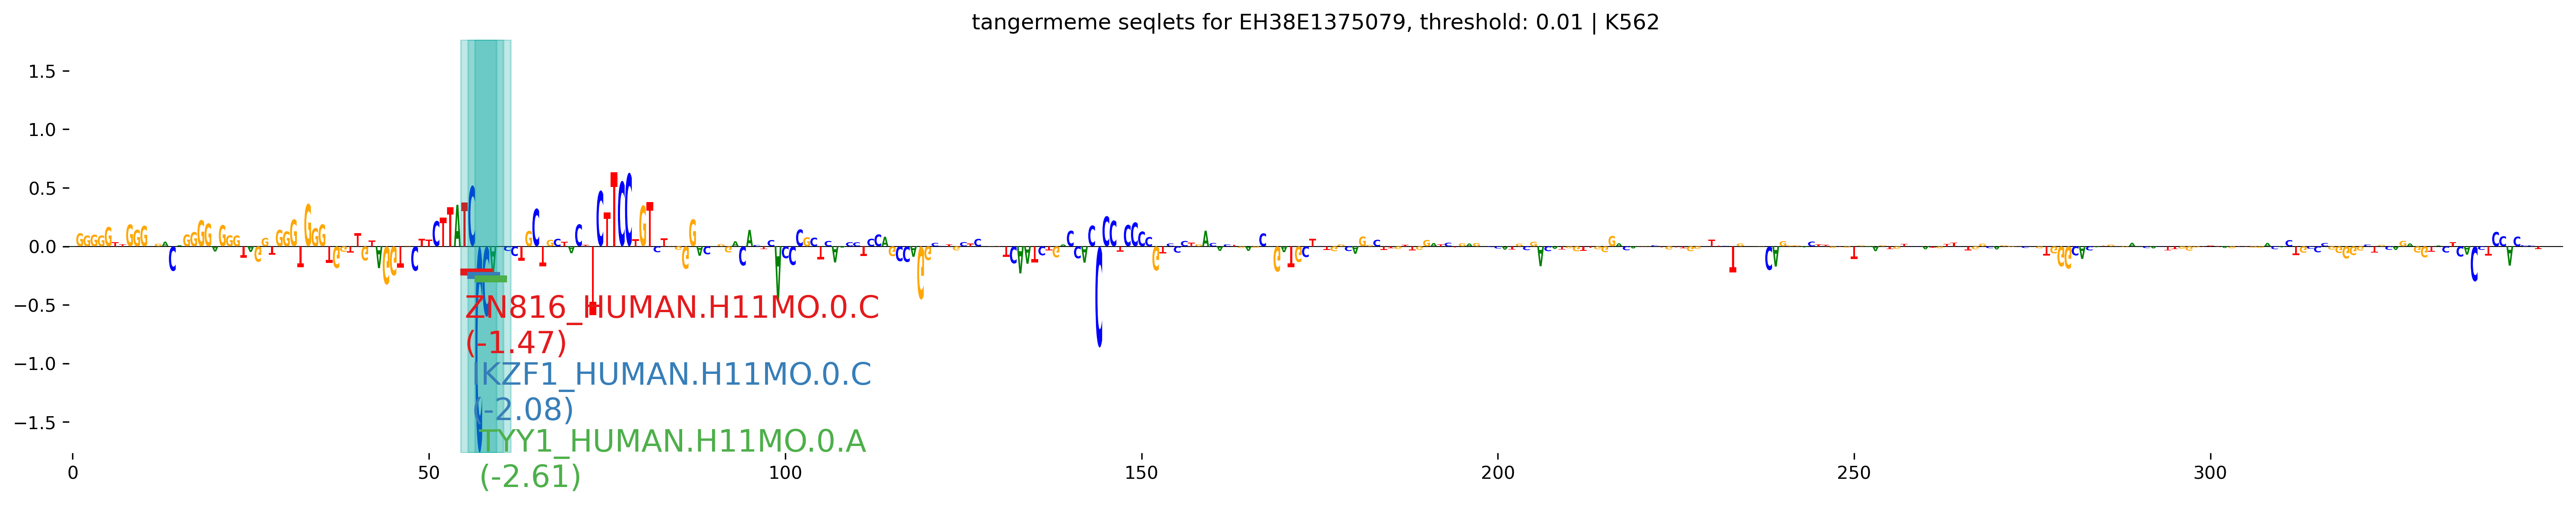

In [16]:
# EH38E1375079
plot_specific_logos(
    annotated_seqlets,
    'K562',
    'EH38E1375079',
    plotLogo_tensors,
    False
)

SKNSH


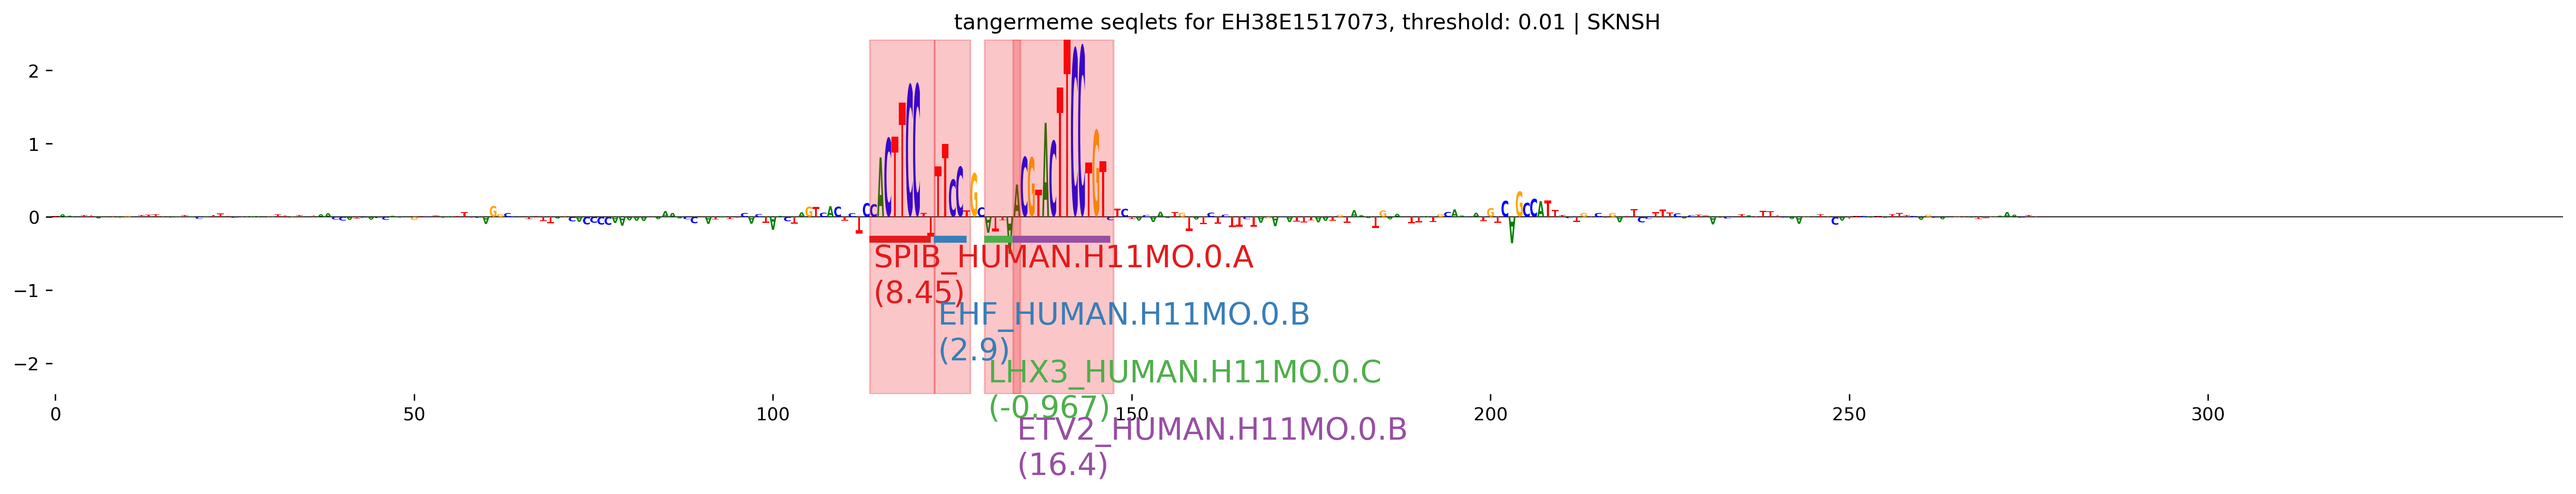

In [8]:
# EH38E1517073
plot_specific_logos(
    annotated_seqlets,
    'SKNSH',
    'EH38E1517073',
    plotLogo_tensors,
    False
)

In [ ]:
# EH38E1314911 GWAS variant
# chr1:6,917,085-6,917,425
# high delta lead variant
# identified in K562
# Ebox/CACCCTG motif
plot_specific_enhancers(
    'EH38E1314911',
    6917085,
    plotLogo_tensors,
    k_mpac_collapsed_dels,
    6917291, # variant pos. - start - 1 - function now does this internally
    [6917292],
    'K562',
    'x'
)

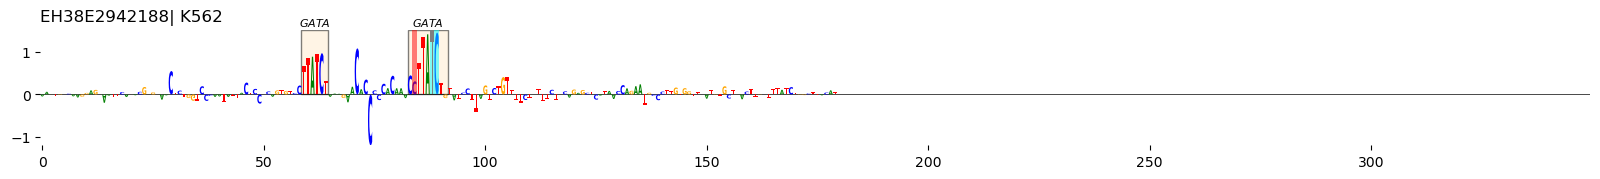

In [77]:
# EH38E2942188 GWAS variant
# chr1:6,917,085-6,917,425
# high delta lead variant
# identified in K562
# Ebox/CACCCTG motif
plot_specific_enhancers(
    'EH38E2942188',
    6316206,
    plotLogo_tensors,
    k_mpac_collapsed_dels,
    6316291, # variant pos. - start - 1 - function now does this internally
    [6316295, 6316296],
    'K562',
    'x'
)

K562


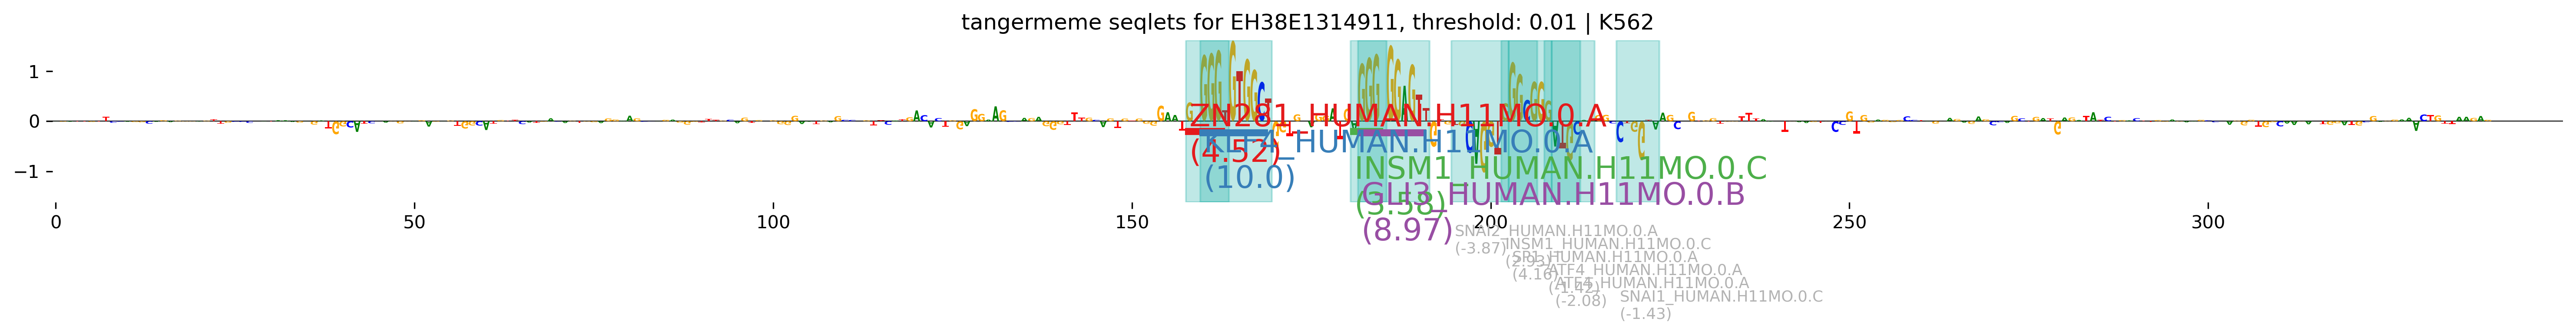

In [27]:
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E1314911',
                    plotLogo_tensors,
                    False)

SKNSH


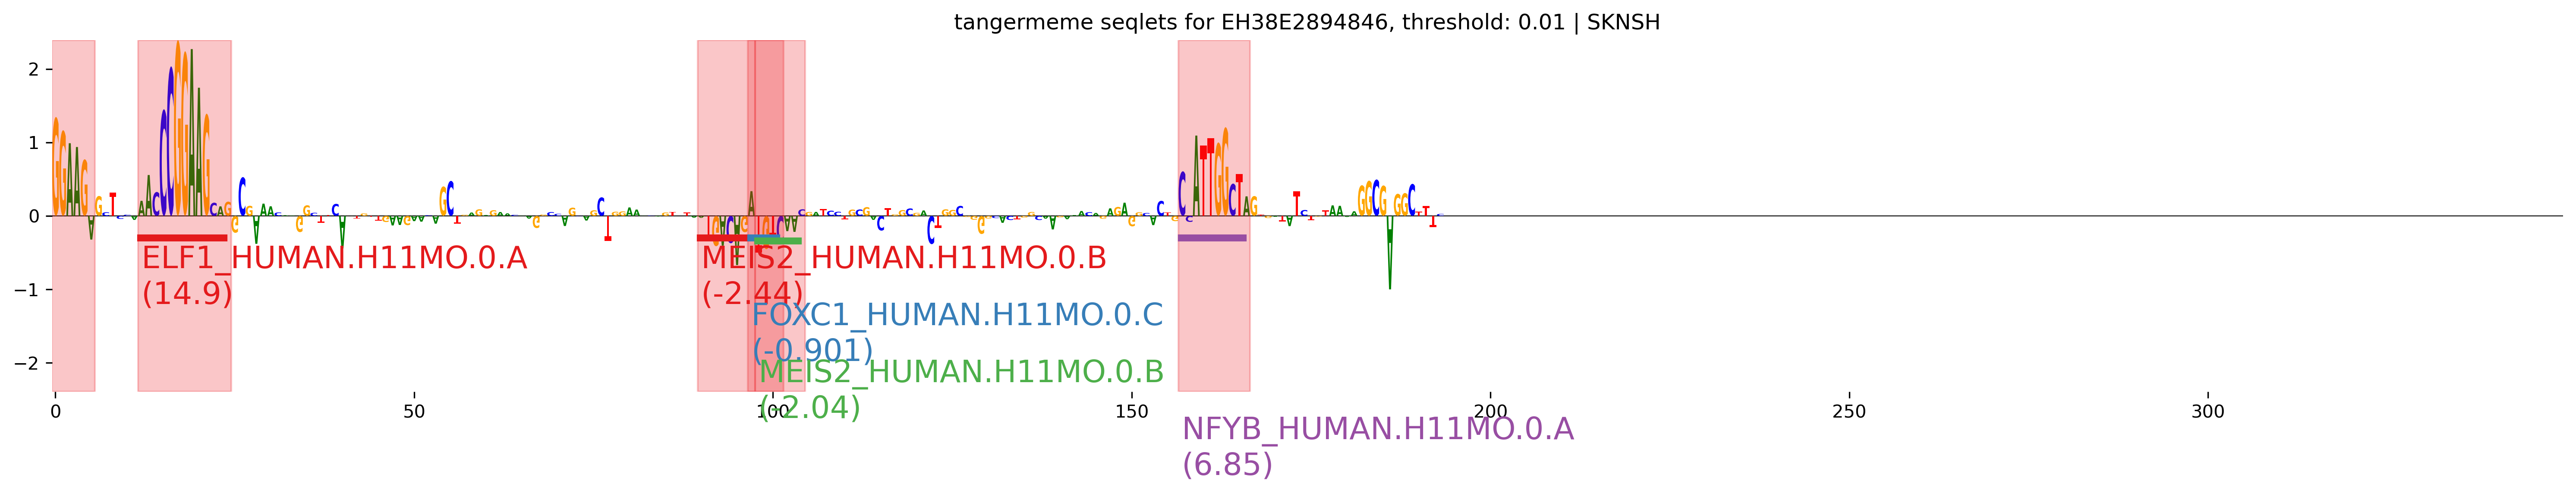

In [18]:
# EH38E2894846 - chr10
# SKNSH
plot_specific_logos(annotated_seqlets,
                    'SKNSH',
                    'EH38E2894846',
                    plotLogo_tensors,
                    False)

K562


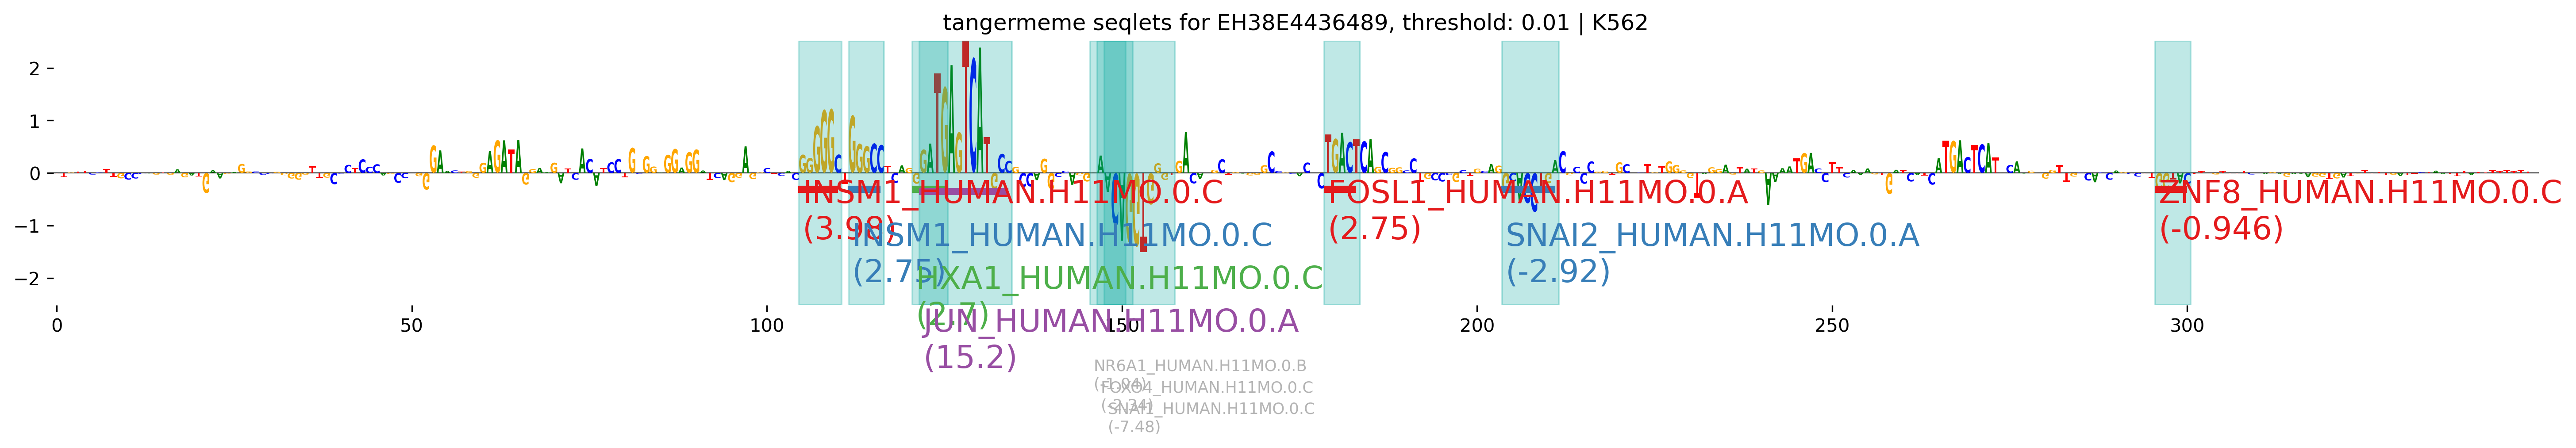

In [11]:
# EH38E4436489 - chr7
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E4436489',
                    plotLogo_tensors,
                    True)

K562


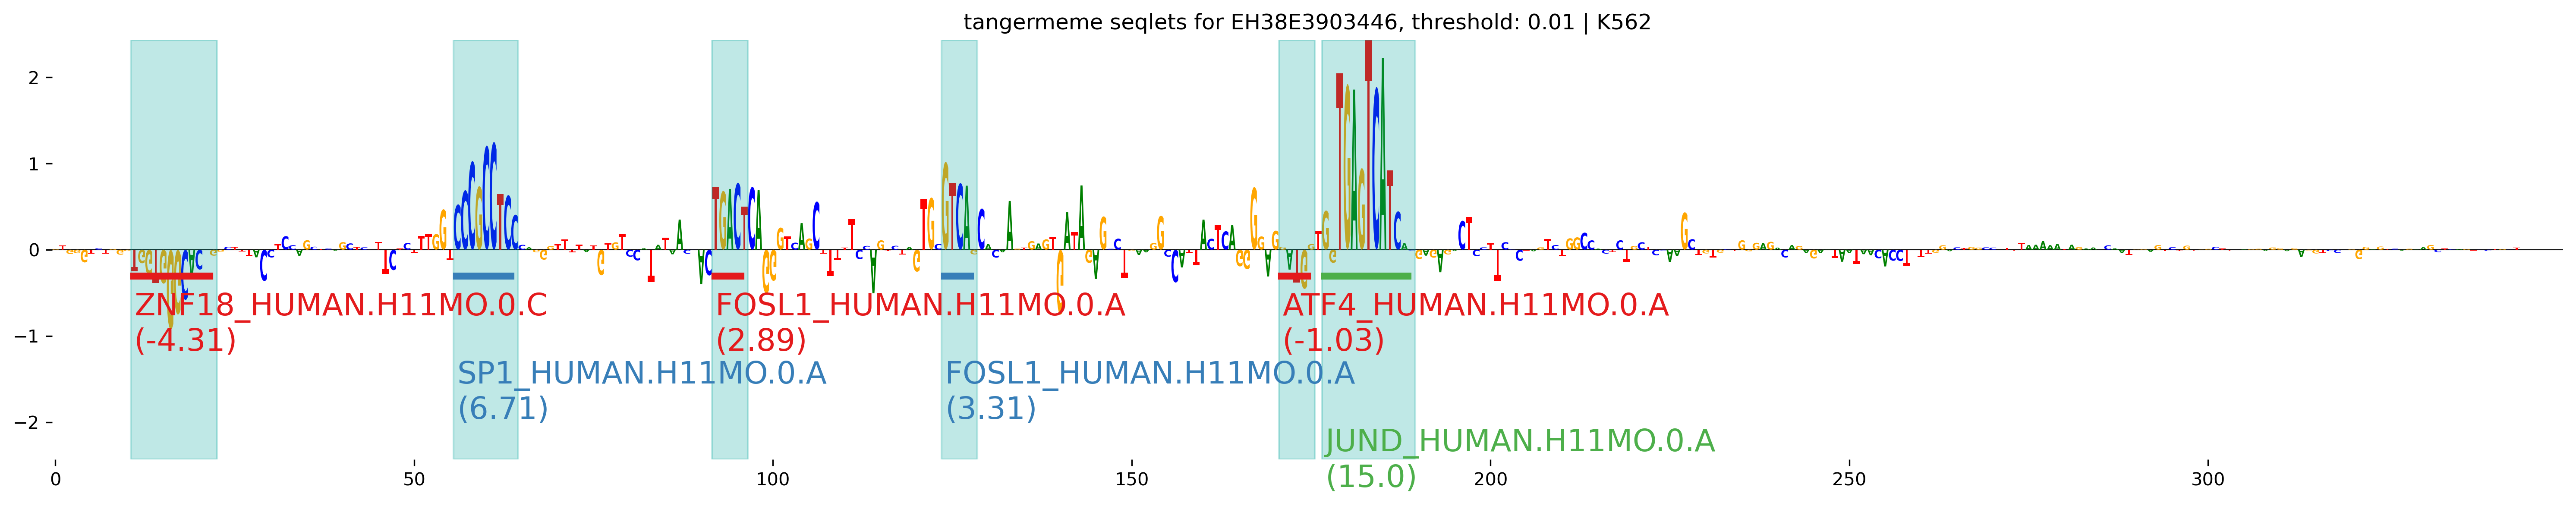

In [7]:
# EH38E3903446 - chr9
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3903446',
                    plotLogo_tensors,
                    True)

K562


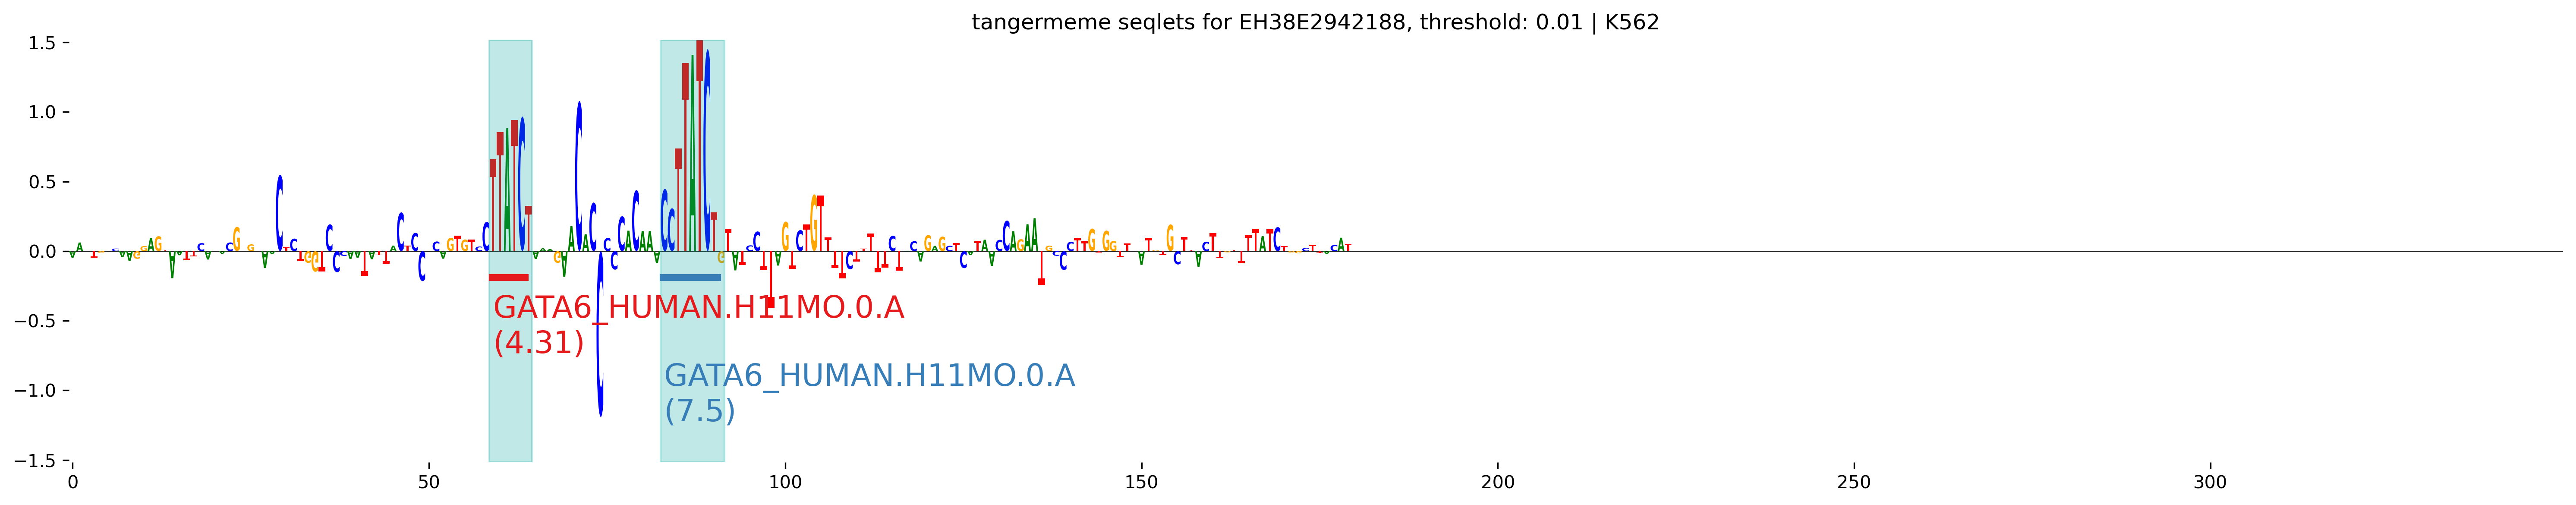

In [16]:
# EH38E2942188 - chr 11
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E2942188',
                    plotLogo_tensors,
                    True)

HepG2


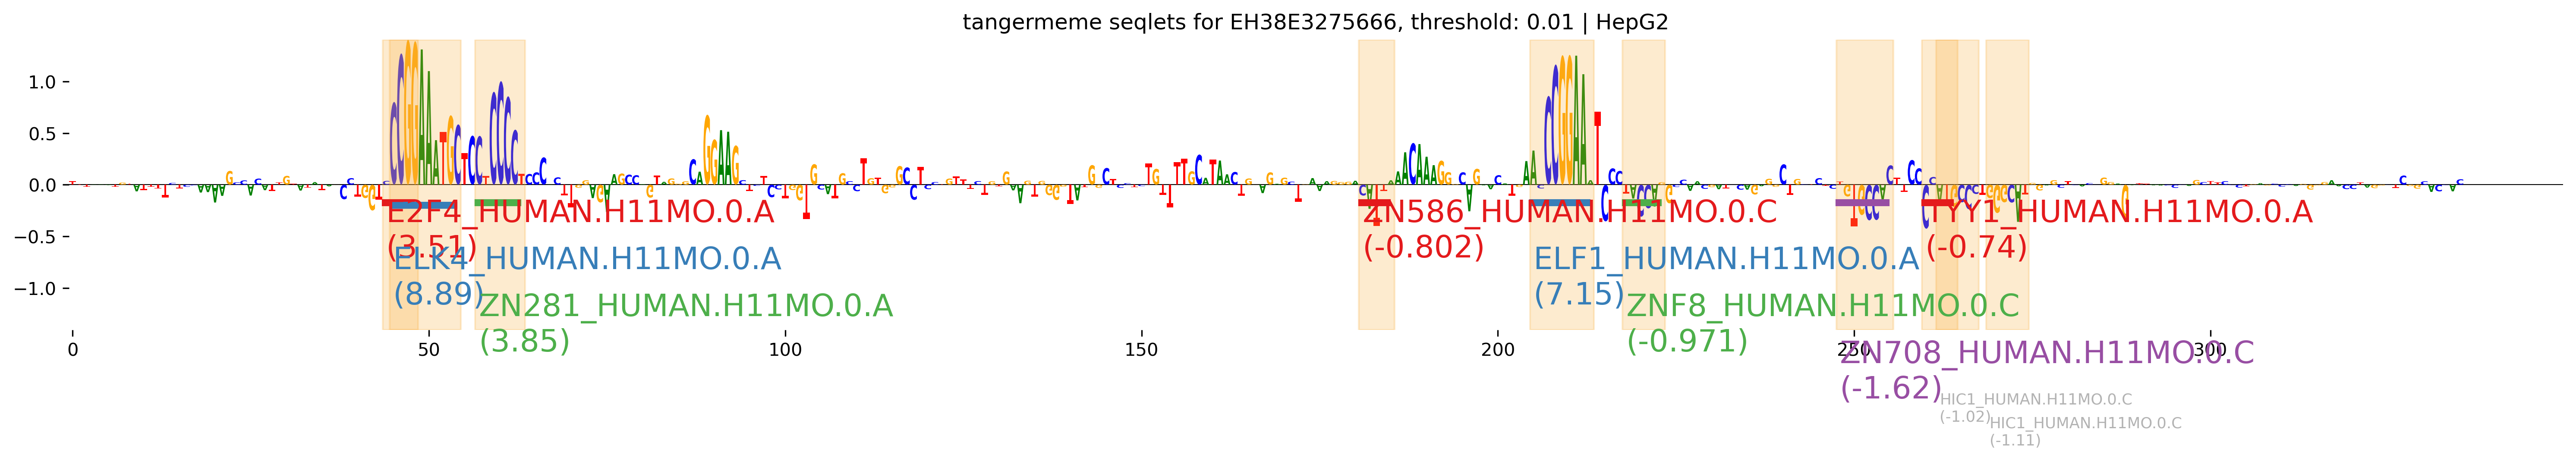

In [12]:
# EH38E3275666 - chr 18
# hepg2
plot_specific_logos(annotated_seqlets,
                    'HepG2',
                    'EH38E3275666',
                    plotLogo_tensors,
                    True)

K562


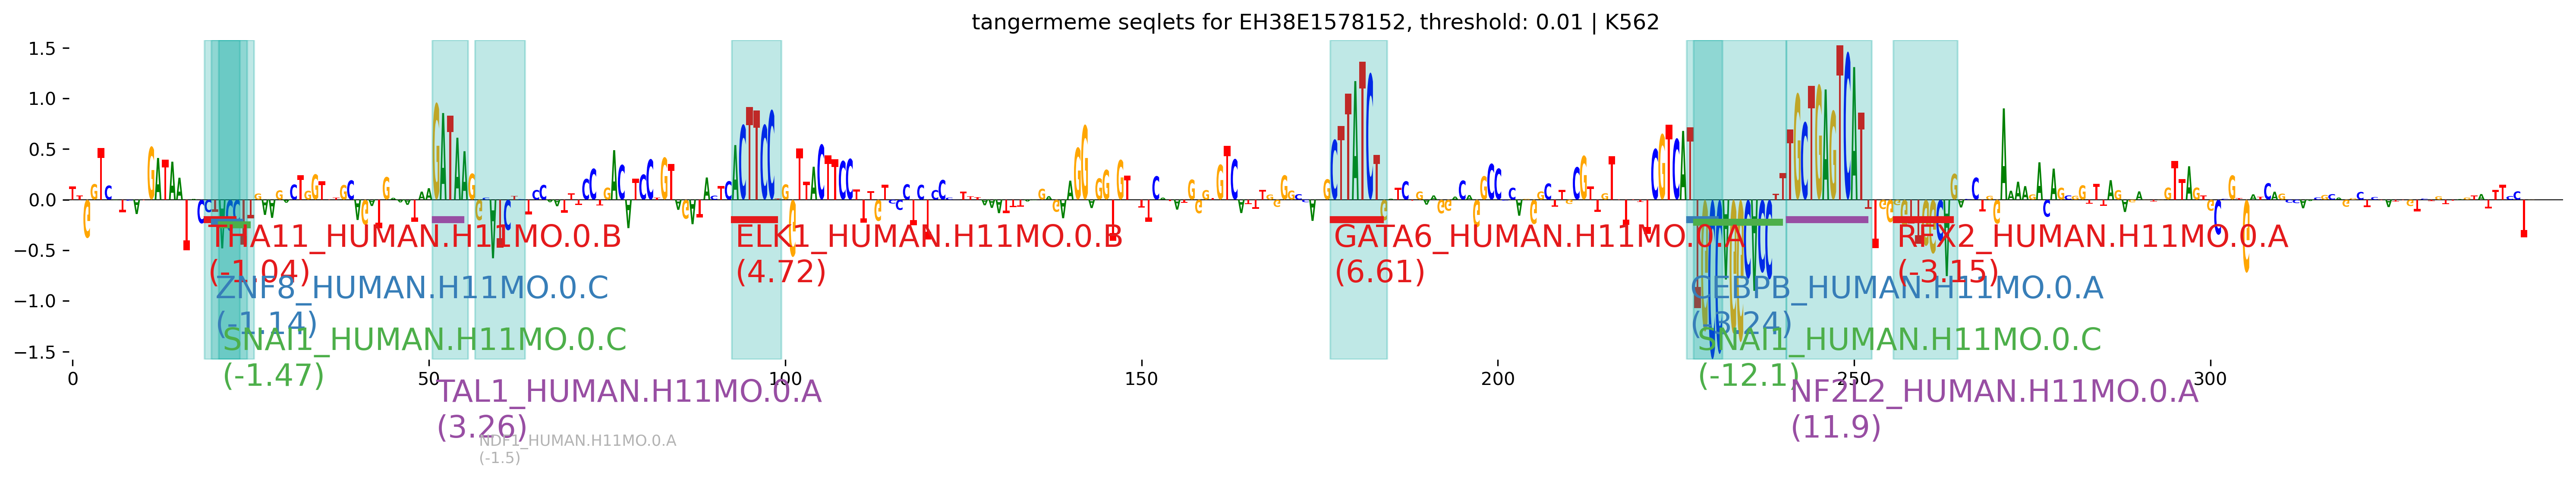

In [7]:
# EH38E1578152 - chr11
# k562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E1578152',
                    plotLogo_tensors,
                    True)

SKNSH


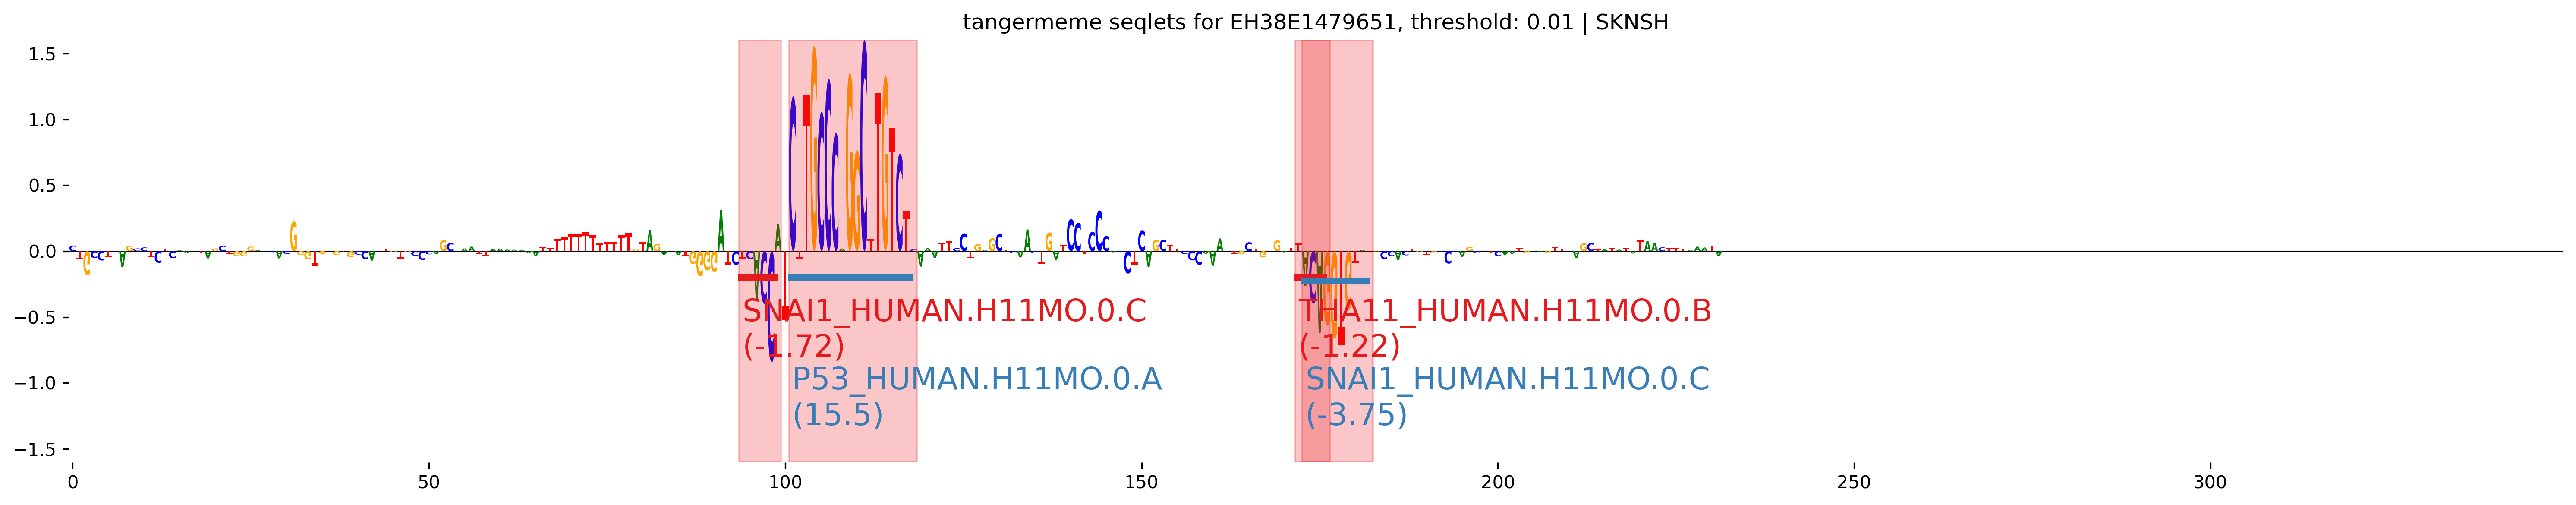

In [7]:
# 'EH38E1479651' - chr10
# sknsh
plot_specific_logos(annotated_seqlets,
                    'SKNSH',
                    'EH38E1479651',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E2864258 - chr1
# k562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E2864258',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E3480167 - chr22
# k562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3480167',
                    plotLogo_tensors,
                    True)
# hepg2
plot_specific_logos(annotated_seqlets,
                    'HepG2',
                    'EH38E3480167',
                    plotLogo_tensors,
                    True)
# sknsh
plot_specific_logos(annotated_seqlets,
                    'SKNSH',
                    'EH38E3480167',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E3536992 - chr3 
# k562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3536992',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E1650154 - che12
# k562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E1650154',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E3489463 - chr22
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3489463',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E2810579 - chr1
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E2810579',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E1311579 - chr1
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E1311579',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E2142374 - chr1
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E0064571',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E2142374 - chr1
# HepG2
plot_specific_logos(annotated_seqlets,
                    'HepG2',
                    'EH38E0064571',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E2142374 - chr21
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E2142374',
                    plotLogo_tensors,
                    True)

In [ ]:
mean_groupy.loc['EH38E2142374',:]

In [ ]:
# EH38E3080592 - chr13
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3080592',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E1650154 - chr12
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E1650154',
                    plotLogo_tensors,
                    True)

In [ ]:
mean_groupy.loc[:,'EH38E1650154']

In [ ]:
# EH38E3862336 - chr8
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3862336',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E3464204 - chr21
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3464204',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E1459202 - chr10
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E1459202',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E2592200 - chr7
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E2592200',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E3768469 - chr7
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3768469',
                    plotLogo_tensors,
                    True)

In [ ]:
# EH38E4286026 - chr22
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E4286026',
                    plotLogo_tensors,
                    True)

In [ ]:
mean_groupy.loc['EH38E4286026',:]

In [ ]:
# EH38E3090869 - chr14
# GATA6
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3090869',
                    plotLogo_tensors,
                    True)

In [ ]:
mean_groupy.loc['EH38E3090869',:]

In [ ]:
# EH38E3275113 - chr18
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E3275113',
                    plotLogo_tensors,
                    True)

In [ ]:
mean_groupy.loc['EH38E3275113',:]

In [ ]:
# EH38E2506437 - chr6
# HepG2
plot_specific_logos(annotated_seqlets,
                    'HepG2',
                    'EH38E2506437',
                    plotLogo_tensors,
                    True)

In [ ]:
mean_groupy.loc['EH38E2506437',:]

In [ ]:
# EH38E1339383
# SKNSH
plot_specific_logos(annotated_seqlets,
                    'SKNSH',
                    'EH38E1339383',
                    plotLogo_tensors,
                    True)

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Set rcParams to ensure fonts are editable in Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

def plot_final_lollipop(numpy_data, title="Alternate Base Analysis"):
    """
    Plots a 2D NumPy array as a series of lollipop plots with several
    customizations for publication quality.

    - Ignores zero-value data points.
    - Removes gridlines.
    - Uses custom legend labels and title.

    Args:
        numpy_data (np.ndarray): A 2D NumPy array of shape (4, N).
        title (str): The title for the plot.
    """
    # --- 1. Input Validation and Data Preparation ---
    if not isinstance(numpy_data, np.ndarray) or numpy_data.ndim != 2 or numpy_data.shape[0] != 4:
        raise ValueError("Input must be a 2D NumPy array with shape (4, N)")

    data = numpy_data
    num_series, num_points = data.shape
    x_values = np.arange(num_points)
    
    # Custom colors and legend labels as requested
    colors = ['green', 'blue', 'gold', 'red']
    legend_labels = ['A', 'C', 'G', 'T']
    
    # --- 2. Create the Plot ---
    # Use a style that is clean and doesn't have a default grid
    plt.style.use('seaborn-v0_8-ticks') 
    fig, ax = plt.subplots(figsize=(20, 3), dpi=300)

    # --- 3. Plot each series, filtering out zeros ---
    for i in range(num_series):
        y_series = data[i]
        
        # Create a mask to select only non-zero values
        non_zero_mask = y_series != 0
        x_plot = x_values[non_zero_mask]
        y_plot = y_series[non_zero_mask]
        
        # Skip plotting if the entire series was zero
        if len(x_plot) == 0:
            continue
            
        # Create the stem plot with the filtered data
        markerline, stemlines, baseline = ax.stem(
            x_plot,
            y_plot,
            label=legend_labels[i],
            basefmt=' '
        )
        
        # Apply custom styling
        plt.setp(stemlines, color='gray', linewidth=0.8)
        plt.setp(markerline, marker='o', markersize=5,
                 markerfacecolor=colors[i],
                 markeredgecolor=colors[i])

    # --- 4. Final Customizations ---
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel("Genomic Position Index", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.set_xlim(-1, num_points)
    
    # Remove gridlines explicitly
    ax.grid(False)
    
    # Add the custom legend
    ax.legend(title='Alt Base', frameon=False, facecolor='white', framealpha=0.8, loc='upper right')
    
    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # Save in both PDF and PNG formats
    plt.savefig('EH38E3390418_lollipop.pdf')
    #plt.savefig("final_lollipop_plot.png", dpi=300)

In [ ]:
plot_final_lollipop(rawTensors['K562']['EH38E3390418'][:,73:-77].cpu().numpy(), 'EH38E3390418')

In [ ]:
rawTensors['K562']['EH38E3390418'][:,73:-77].shape